> **READ ONLY — archive snapshot.**
> Amplitude SNR with signal level $\bar I = \mathrm{mean}(I_{\mathrm{clean}})$ (not RMS). Preserved before switching to $A_s = \sqrt{\mathrm{mean}(I^2)}$ in the active notebook / `trace_noise.py`.
> Do not edit; use `reconstruction_snr_experiments.ipynb` for current work.

# Toward error vs. SNR: first working slice

**Goal:** plot **pulse reconstruction error vs. trace SNR** (test set, after training).

**This notebook:** supervised **train + validation + test** on simulated FROG traces.

- **Model:** imported from an **external module** (not defined here).
- **Noise on traces:** AWGN on FROG intensity with **amplitude** SNR in dB ($\rho=\bar I/\sigma_n$, $\rho=10^{\mathrm{SNR}_{\mathrm{dB}}/20}$; see **Trace SNR, AWGN, and SNR$_1$** in `trace_noise.py`).
- **Forward physics:** `FROGNet` from `frognet.py`.

Training uses random SNR per batch; validation uses a fixed `VAL_SNR_DB` and plots L1 vs. epoch. After training: SNR sweep on **test** and error-vs-SNR plot (secondary x-axis: equivalent pulse count $N$ from SNR$_1$).


**Code cell below:**
- Imports (PyTorch, plotting, data loaders).
- External **model** (`TraceToPulseCNN`) and **noise** (`add_trace_noise` from `trace_noise`).
- Project helpers: pulse generation + `FROGNet`.

In [1]:
from __future__ import annotations

from typing import Callable

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

from data_generation import generate_pulses_gaussian
from frognet import FROGNet

# --- External model (replace module/class as needed) ---
from frog_reconstruction_model import TraceToPulseCNN

# --- External trace noise (replace module/function as needed; not required to be utils.py) ---
from trace_noise import add_trace_noise_awgn

import importlib
import pulse_metrics
importlib.reload(pulse_metrics)  # pick up edits without kernel restart
from pulse_metrics import l1_packed_per_pulse_torch, pulse_packed_l1_loss_torch

add_trace_noise: Callable[[torch.Tensor, float], torch.Tensor] = add_trace_noise_awgn

**Code cell below:**
- `DEVICE`, random seed, grid size `N`.
- Dataset sizes (train / val / **test**), batch size, epochs, learning rate.
- Train SNR range, fixed validation SNR (`VAL_SNR_DB`), SNR sweep grid, checkpoint path.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

N = 64  # time samples; FROG trace [B, N, N] when num_delay_steps == N

# Pulse synthesis — same as pulses_generator_NB.ipynb
T_TOTAL = 250.0  # attoseconds, full time window
DT = T_TOTAL / N
SIGMA_OMEGA = 0.05 * (2 * np.pi / DT)
SIGMA_GAUSS = 1.6
PHASE_SCALE = np.pi
ENERGY_SCALE_EV = 658.2  # ω [rad/as] → Energy [eV], same as pulses_generator_NB.ipynb
N_TRAIN = 2048
N_VAL = 512
N_TEST = 512
BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3

TRAIN_SNR_DB_RANGE = (0.0, 30.0)
VAL_SNR_DB = 15.0
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)  # -10, -5, 0, 5, ..., 30 dB

# --- Experiments: baseline stays; add advanced runs alongside (not replacing) ---
RUN_BASELINE_TRAINING = False  # False → load baseline checkpoint only

EXPERIMENTS = [
    {
        "name": "baseline_2k",
        "run_training": RUN_BASELINE_TRAINING,
        "checkpoint": "checkpoints/baseline_2k.pt",
        "sweep_cache": "checkpoints/baseline_2k_cnn_sweep.npz",
        "force_recompute_sweep": False,
        "primary": True,  # used for single-pulse CNN vs PCGPA plots
        "model_name": "cnn",
    },
    # After: python scripts/train_trace_to_pulse.py --checkpoint checkpoints/large_60k.pt
    {
         "name": "large_60k",
         "run_training": False,
         "checkpoint": "checkpoints/large_60k.pt",
         "sweep_cache": "checkpoints/large_60k_cnn_sweep.npz",
         "force_recompute_sweep": False,
         "primary": False,
         "model_name": "cnn",
     },
    # Smoke / full run with enlarged CNN:
     {
         "name": "large_60k_cnn_large",
         "run_training": False,
         "checkpoint": "checkpoints/large_60k_cnn_large.pt",
         "sweep_cache": "checkpoints/large_60k_cnn_large_cnn_sweep.npz",
         "force_recompute_sweep": False,
         "primary": False,
         "model_name": "cnn_large",
     },
    {
        "name": "large_100k_cnn_large",
        "run_training": False,
        "checkpoint": "checkpoints/large_100k_cnn_large.pt",
        "sweep_cache": "checkpoints/large_100k_cnn_large_cnn_sweep.npz",
        "force_recompute_sweep": False,
        "primary": False,
        "model_name": "cnn_large",
    },
]

# CNN-only overlay plots (keep short — do not add baseline / PCGPA here)
CNN_COMPARE_NAMES = [
    "large_60k_cnn_large",
    "large_100k_cnn_large",
]

CHECKPOINT_PATH = EXPERIMENTS[0]["checkpoint"]  # legacy alias

PCGPA_MAXITER = 200
PCGPA_N_RESTARTS = 3
PCGPA_N_TEST = 32  # lower (e.g. 8) for quick sweeps; N_TEST for full paper run
RUN_PCGPA_SWEEP = True
FORCE_RECOMPUTE_PCGPA = False  # set False to load checkpoints/pcgpa_snr_sweep.npz
PCGPA_SWEEP_CACHE = "checkpoints/pcgpa_snr_sweep.npz"
RUN_PCGPA_INIT_COMPARE = True
FORCE_RECOMPUTE_PCGPA_INIT = True
PCGPA_INIT_COMPARE_CACHE = "checkpoints/pcgpa_init_guess_compare.npz"
PCGPA_INIT_N_RESTARTS = 1  # one restart per initial-guess scenario

print("DEVICE:", DEVICE)


DEVICE: cpu


## Trace SNR, AWGN, and the single-pulse reference SNR$_1$

This notebook uses **amplitude SNR** (not power SNR) on FROG **intensity** traces. Two related quantities appear:

1. **Trace SNR** — sets AWGN on simulated traces during training and evaluation (`trace_noise.py`).
2. **SNR$_1$** — single-pulse reference for mapping trace SNR to an **equivalent pulse count** $N_{\mathrm{eq}}$ on secondary plots (`snr_db_to_equivalent_n_pulses` in `pulse_metrics.py`).

---

### 1. Signal and noise on one trace pixel

**Clean trace.** For each pulse, $E(t)$ is propagated through `FROGNet` to an intensity trace

$$
I_{\mathrm{clean}}(\omega,\tau) = \left| \tilde{G}(\omega,\tau) \right|^2
$$

(non-negative SHG-FROG intensity; stored as `I_train`, `I_val`, `I_test`).

**Signal amplitude per pixel.** At every pixel the **signal** is the FROG **intensity** $I$ (not $\sqrt{I}$). The scalar level used for SNR is the **mean over all** $\omega$ and $\tau$ samples in that trace:

$$
\bar I \equiv \mathrm{mean}\bigl(I_{\mathrm{clean}}\bigr).
$$

**SNR is an amplitude ratio**, not a power ratio:

$$
\rho \equiv \mathrm{SNR}_{\mathrm{lin}} = \frac{\bar I}{\sigma_n},
$$

where $\sigma_n$ is the **standard deviation** of the additive noise on each pixel (not $\sigma_n^2$).

---

### 2. Decibels $\leftrightarrow$ linear SNR (amplitude)

$$
\mathrm{SNR}_{\mathrm{dB}} = 20 \log_{10}(\rho)
\qquad\Leftrightarrow\qquad
\rho = 10^{\mathrm{SNR}_{\mathrm{dB}}/20}.
$$

(`snr_db_to_linear` / `snr_linear_to_db` in `trace_noise.py`.)

- Training draws $\mathrm{SNR}_{\mathrm{dB}}$ uniformly in `TRAIN_SNR_DB_RANGE`, then uses $\rho = 10^{\mathrm{SNR}_{\mathrm{dB}}/20}$ inside `add_trace_noise_awgn`.
- Sweeps use fixed values in `SNR_SWEEP_DB`; each point applies the same dB $\to$ linear conversion before adding noise.

---

### 3. AWGN on the trace (`trace_noise.py`)

For a requested $\mathrm{SNR}_{\mathrm{dB}}$:

$$
\rho = 10^{\mathrm{SNR}_{\mathrm{dB}}/20},
\qquad
\sigma_n = \frac{\bar I}{\rho}.
$$

**Additive WGN** — independent Gaussian noise on every trace pixel:

$$
n \sim \mathcal{N}(0,\,\sigma_n^2),
\qquad
I_{\mathrm{noisy}} = I_{\mathrm{clean}} + n.
$$

(`add_trace_noise_awgn`: `noise = randn_like(I) * sigma_n`.)

**Note:** $\bar I$ depends on the simulated pulse and FROG forward model; it is **not** fixed to the reference $A_{s1}$ below. SNR$_1$ enters only when mapping trace SNR to $N_{\mathrm{eq}}$, not when drawing AWGN on a given trace.

---

### 4. $N$ measurements: scaling of mean signal and noise

Average over **$N$ independent measurements** (each trace pixel carries FROG intensity; averages are over pixels **and** over the $N$ shots):

| Quantity | Single measurement | $N$ averaged measurements |
|----------|-------------------|---------------------------|
| Mean signal (over pixels) | $\bar I_1$ | $\bar I_N = N\,\bar I_1$ |
| Mean noise std (over pixels) | $\sigma_1$ | $\sigma_N = \sqrt{N}\,\sigma_1$ |

Therefore the **linear amplitude SNR** scales as

$$
\rho_N = \frac{\bar I_N}{\sigma_N}
= \frac{N\,\bar I_1}{\sqrt{N}\,\sigma_1}
= \sqrt{N}\,\rho_1.
$$

Equivalently, the number of pulses is the ratio of **squared** linear SNRs:

$$
N = \left(\frac{\rho_N}{\rho_1}\right)^2.
$$

---

### 5. Single-pulse reference SNR$_1$

Defaults in `snr_db_to_equivalent_n_pulses`:

- **Photons per pulse:** $N_{\mathrm{ph}} = 10^{12}$ (`photons_per_pulse`)
- **Process efficiency:** $\eta = 10^{-12}$ (`efficiency`)

Reference **signal amplitude** (mean FROG intensity scale for one pulse):

$$
A_{s1} = \eta \times N_{\mathrm{ph}} = 10^{-12} \times 10^{12} = 1.
$$

Reference **noise standard deviation** per pixel (one pulse):

$$
\sigma_{n1} = 80 \times A_{s1} = 80
\quad\text{(`pn1_over_ps1 = 80`).}
$$

**Single-pulse linear SNR:**

$$
\rho_1 \equiv \mathrm{SNR}_1 = \frac{A_{s1}}{\sigma_{n1}} = \frac{1}{80},
$$

i.e. about **−38.1 dB** ($20\log_{10}(1/80)$).

| Quantity | Value | Code parameter |
|----------|-------|----------------|
| $N_{\mathrm{ph}}$ | $10^{12}$ photons / pulse | `photons_per_pulse` |
| $\eta$ | $10^{-12}$ | `efficiency` |
| $A_{s1}=\eta N_{\mathrm{ph}}$ | $1$ | — |
| $\sigma_{n1}$ | $80\,A_{s1}$ | `pn1_over_ps1 = 80` |
| $\rho_1 = A_{s1}/\sigma_{n1}$ | $1/80$ | — |

**Equivalent pulse count** (secondary plots): for trace SNR in dB, convert to $\rho_N = 10^{\mathrm{SNR}_{\mathrm{dB}}/20}$ and invert

$$
\rho_N = \mathrm{SNR}_1 \sqrt{N_{\mathrm{eq}}}
\quad\Rightarrow\quad
N_{\mathrm{eq}} = \left(\frac{\rho_N}{\mathrm{SNR}_1}\right)^2
= \left(\frac{10^{\mathrm{SNR}_{\mathrm{dB}}/20}}{\mathrm{SNR}_1}\right)^2.
$$

(`snr_db_to_equivalent_n_pulses` in `pulse_metrics.py`.)


**Code cell below:**
- Generate synthetic pulses; pack to `[B, 2N]`.
- Forward through `FROGNet` → clean traces `I_train`, `I_val`, `I_test`.
- Build train / val / **test** `DataLoader`s (noise added later in the loop).

In [3]:
from dataset_utils import PulseGridConfig, build_frog_dataloaders

_grid = PulseGridConfig(
    n=N,
    t_total=T_TOTAL,
    sigma_omega=SIGMA_OMEGA,
    sigma_gauss=SIGMA_GAUSS,
    phase_scale=PHASE_SCALE,
)

_bundle = build_frog_dataloaders(
    n_train=N_TRAIN,
    n_val=N_VAL,
    n_test=N_TEST,
    batch_size=BATCH_SIZE,
    seed=SEED,
    device=DEVICE,
    grid=_grid,
)
train_loader = _bundle.train_loader
val_loader = _bundle.val_loader
test_loader = _bundle.test_loader
t_vec = _bundle.t_vec
w_vec = _bundle.w_vec

I_test = test_loader.dataset.tensors[0]
E_test = test_loader.dataset.tensors[1]

print("train batches:", len(train_loader), "test pulses:", I_test.shape[0])


train batches: 32 test pulses: 512


**Code cell below:**
- Instantiate imported `TraceToPulseCNN` on `DEVICE`.
- One dummy forward (for `LazyLinear`); print parameter count.

In [4]:
from train import build_model

_init_model_name = EXPERIMENTS[0].get("model_name", "cnn")
model = build_model(N, DEVICE, model_name=_init_model_name)
print(f"Model: {_init_model_name}")
print("Parameters:", sum(p.numel() for p in model.parameters()))


Model: cnn
Parameters: 4266208


**Code cell below:**
- Train loop: random $\mathrm{SNR}_{\mathrm{dB}}$ → convert to linear → `add_trace_noise` (AWGN on trace; see **Trace SNR, AWGN, and SNR$_1$**) → model → L1 loss → Adam.
- Val loop each epoch: fixed `VAL_SNR_DB`, mean L1 on val set.
- Print train/val loss per epoch; store curves in lists.

In [5]:
from train import TrainConfig, load_checkpoint, save_checkpoint, train_trace_to_pulse

_baseline = EXPERIMENTS[0]
_train_cfg = TrainConfig(
    n=N,
    n_train=N_TRAIN,
    n_val=N_VAL,
    n_test=N_TEST,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    train_snr_db_range=TRAIN_SNR_DB_RANGE,
    val_snr_db=VAL_SNR_DB,
    seed=SEED,
    checkpoint_path=_baseline["checkpoint"],
    experiment_name=_baseline["name"],
    model_name=_baseline.get("model_name", "cnn"),
    device=str(DEVICE),
)

if _baseline["run_training"]:
    _history = train_trace_to_pulse(
        model,
        train_loader,
        val_loader,
        epochs=_train_cfg.epochs,
        lr=_train_cfg.lr,
        train_snr_db_range=_train_cfg.train_snr_db_range,
        val_snr_db=_train_cfg.val_snr_db,
        add_noise_fn=add_trace_noise,
    )
    _ckpt = save_checkpoint(_baseline["checkpoint"], model, _train_cfg, _history)
    train_losses = _history.train_losses
    val_l1_pulses = _history.val_l1_pulses
    print("Saved:", _ckpt)
else:
    model, _ckpt_data = load_checkpoint(_baseline["checkpoint"], DEVICE)
    train_losses = _ckpt_data.get("train_losses", [])
    val_l1_pulses = _ckpt_data.get("val_l1_pulses", [])
    print(f"Loaded baseline from {_baseline['checkpoint']}")

print("Done.")


Loaded baseline from checkpoints/baseline_2k.pt
Done.


**Code cell below:**
- Plot **train** and **val** mean L1 vs. epoch on the **same axes**.
- Legend + grid; `plt.show()`.

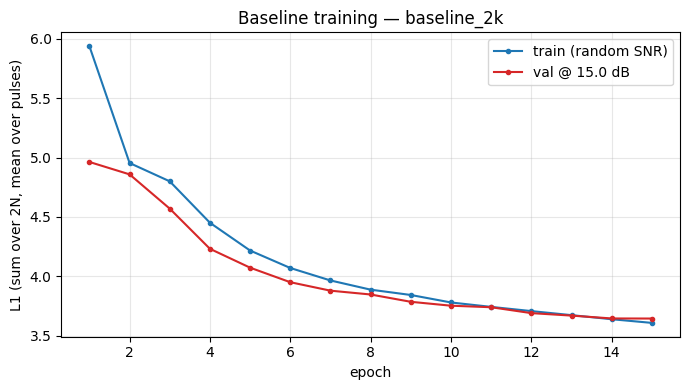

In [6]:
from evaluate_cnn import plot_training_history

if train_losses:
    plot_training_history(
        train_losses,
        val_l1_pulses,
        val_snr_db=VAL_SNR_DB,
        title=f"Baseline training — {_baseline['name']}",
    )
else:
    print("No training history in checkpoint.")


**Code cell below** (run after training — do not re-run the train cell):

- `l1_stats_at_snr` — per test pulse: fixed-SNR noise → predict → L1; return **mean ± std** over pulses.
- Save model weights to `CHECKPOINT_PATH`.
- Loop over `SNR_SWEEP_DB` (−10…30 dB); at each SNR, AWGN on traces per **Trace SNR, AWGN, and SNR$_1$**; print mean ± std L1.
- Plot: X = trace SNR (dB), Y = mean L1 with **error bars** (±1 std over test pulses).

baseline test L1 @ -10.0 dB = 3.93081 ± 1.62624
baseline test L1 @ -5.0 dB = 3.68424 ± 1.70625
baseline test L1 @ 0.0 dB = 3.60236 ± 1.76148
baseline test L1 @ 5.0 dB = 3.58505 ± 1.77254
baseline test L1 @ 10.0 dB = 3.58005 ± 1.78304
baseline test L1 @ 15.0 dB = 3.58281 ± 1.78253
baseline test L1 @ 20.0 dB = 3.58175 ± 1.78290
baseline test L1 @ 25.0 dB = 3.58153 ± 1.78346
baseline test L1 @ 30.0 dB = 3.58160 ± 1.78315


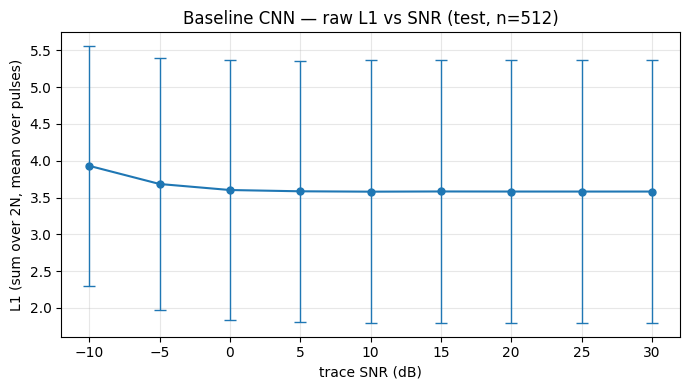

In [7]:
from evaluate_cnn import l1_stats_at_snr

# Quick baseline-only raw L1 vs SNR (separate from multi-experiment sweep below)
test_l1_mean: list[float] = []
test_l1_std: list[float] = []
for snr_db in SNR_SWEEP_DB:
    mean_err, std_err = l1_stats_at_snr(
        model, test_loader, float(snr_db), add_noise_fn=add_trace_noise
    )
    test_l1_mean.append(mean_err)
    test_l1_std.append(std_err)
    print(f"baseline test L1 @ {snr_db:.1f} dB = {mean_err:.5f} ± {std_err:.5f}")

plt.figure(figsize=(7, 4))
plt.errorbar(
    SNR_SWEEP_DB,
    test_l1_mean,
    yerr=test_l1_std,
    fmt="-o",
    markersize=5,
    capsize=4,
    elinewidth=1,
)
plt.xlabel("trace SNR (dB)")
plt.ylabel("L1 (sum over 2N, mean over pulses)")
plt.title(f"Baseline CNN — raw L1 vs SNR (test, n={N_TEST})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
model

TraceToPulseCNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU(inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=8192, out_features=512, bias=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=512, out_features=128, bias=True)
  )
)

## PCGPA baseline (classical)

`pcgpa_reconstruct.py` runs PCGPA on the **same** FROGNet traces `[N_ω, N_τ]` (random initial guess; no ground-truth spectrum). Noisy traces use the same AWGN / dB $\to$ linear rules as the CNN (**Trace SNR, AWGN, and SNR$_1$**). SNR sweep: **four** plots vs trace SNR (dB) and **four** vs $N_{\mathrm{eq}}$ from $\mathrm{SNR}_N=\mathrm{SNR}_1\sqrt{N_{\mathrm{eq}}}$. Metrics: **SIMILARITY_ERROR** and L1. **PCGPA** always uses best ambiguity; **CNN** raw vs best ambiguity. Above: overlay $|E(t)|$ @ 30 dB.

Requires:
- `vendor/pypret`: `git clone --depth 1 https://github.com/ncgeib/pypret.git vendor/pypret`
- Python packages (in your notebook venv): `pip install h5py scipy`

**Run all cells above first** (imports → hyperparameters → data/`I_test` → model → training or load checkpoint). PCGPA cells use `I_test`, `E_test`, `SEED`, `PCGPA_MAXITER`, `add_trace_noise`.

In [9]:
import os

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import pcgpa_reconstruct
from pulse_metrics import best_delta_e_ambiguity, unpack_packed_field

pcgpa_reconstruct = pcgpa_reconstruct.reload_from_disk()
print("pcgpa_reconstruct:", pcgpa_reconstruct.__file__)
reconstruct_pcgpa = pcgpa_reconstruct.reconstruct_pcgpa

_pcgpa_prereq = ("I_test", "E_test", "SEED", "PCGPA_MAXITER", "add_trace_noise")
_missing = [n for n in _pcgpa_prereq if n not in globals()]
if _missing:
    raise RuntimeError(
        "Run earlier notebook cells first (data + hyperparameters). Missing: "
        + ", ".join(_missing)
    )

# --- smoke test: one test pulse, clean trace ---
_i = 0
_i_clean = I_test[_i].cpu().numpy()
_e_ref = unpack_packed_field(E_test[_i].cpu().numpy())
_e_pcgpa = reconstruct_pcgpa(
    _i_clean,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_restarts=PCGPA_N_RESTARTS,
    rng=np.random.default_rng(SEED),
)
print(
    "PCGPA smoke (clean trace), best δE:",
    f"{best_delta_e_ambiguity(_e_pcgpa, _e_ref):.6f} rad",
)

_i_noisy = add_trace_noise(I_test[_i : _i + 1], 10.0).squeeze(0).cpu().numpy()
_e_pcgpa_noisy = reconstruct_pcgpa(
    _i_noisy,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_restarts=PCGPA_N_RESTARTS,
    rng=np.random.default_rng(SEED + 1),
)
print(
    "PCGPA smoke (10 dB), best δE:",
    f"{best_delta_e_ambiguity(_e_pcgpa_noisy, _e_ref):.6f} rad",
)

pcgpa_reconstruct: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\pcgpa_reconstruct.py
PCGPA smoke (clean trace), best δE: 0.253104 rad
PCGPA smoke (10 dB), best δE: 0.277381 rad


## CNN vs. PCGPA: recovered vs. true pulse @ 30 dB

One test pulse @ 30 dB: two **2×2** figures (CNN vs. PCGPA, $|E|$ + phase) — **best L1** (`best_l1_ambiguity_field`) and **best δE** (`best_ambiguity_field`); then clean/noisy SHG-FROG trace. Printed metrics match the plotted aligned fields.

Running PCGPA @ 30 dB (maxiter=200, restarts=3) …
L1 @ 30 dB, pulse 0 (baseline_2k): CNN raw=3.37619  CNN L1-best=3.67536  PCGPA L1-best=2.50467
δE @ 30 dB, pulse 0: CNN δE-best=0.4321 rad  PCGPA δE-best=0.3027 rad


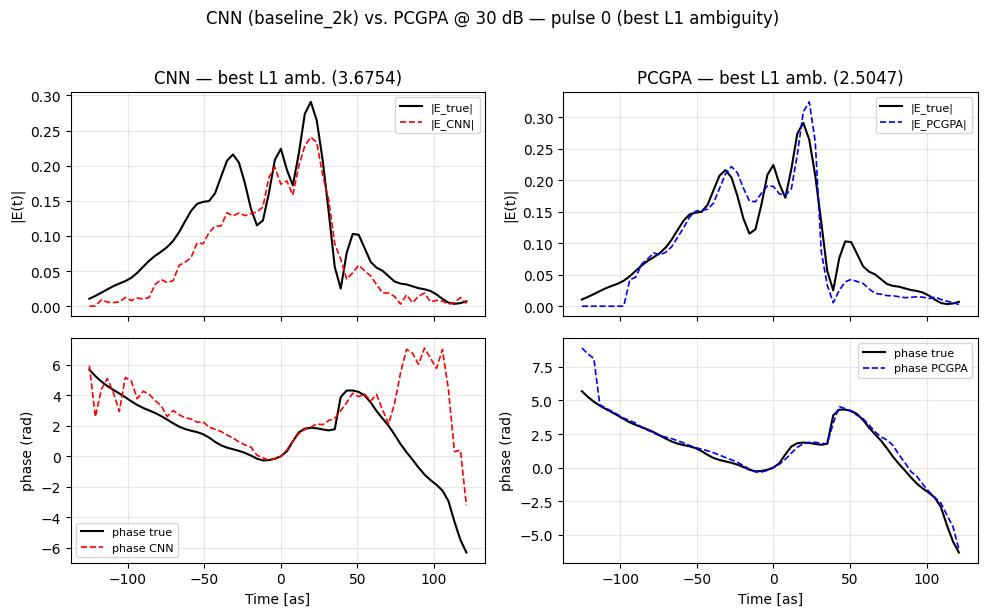

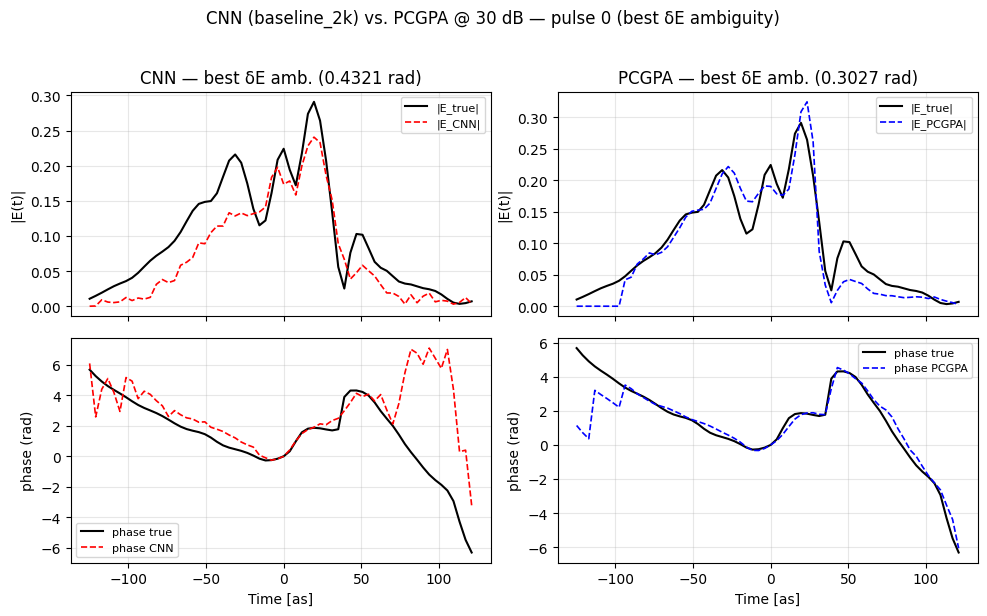

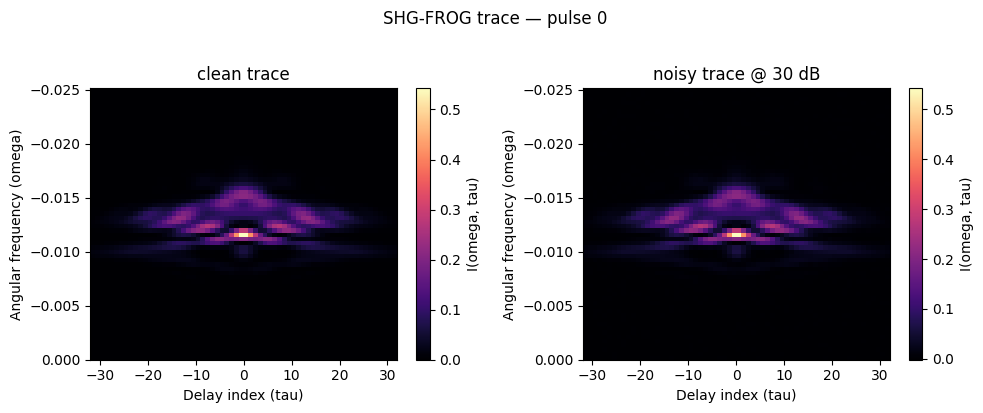

In [10]:
import importlib
import os

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import pcgpa_reconstruct
import pulse_metrics

importlib.reload(pulse_metrics)
from pulse_metrics import (
    best_ambiguity_field,
    best_l1_ambiguity_field,
    delta_e_numpy,
    l1_packed_mae,
    packed_batch_to_complex,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)
from train import load_checkpoint

_pcgpa_mod = pcgpa_reconstruct.reload_from_disk()
reconstruct_pcgpa = _pcgpa_mod.reconstruct_pcgpa
_pcgpa_rng_for_pulse = _pcgpa_mod._pcgpa_rng_for_pulse

_primary = next(e for e in EXPERIMENTS if e.get("primary"))
model, _ = load_checkpoint(_primary["checkpoint"], DEVICE)

_PLOT_SNR_DB = 30.0
_plot_i = 0

model.eval()
with torch.no_grad():
    I_clean_1 = I_test[_plot_i : _plot_i + 1]
    I_n = add_trace_noise(I_clean_1, _PLOT_SNR_DB)
    E_pred = model(I_n.unsqueeze(1))

_i_noisy_np = I_n.squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())
e_rec = packed_batch_to_complex(E_pred)[0]
e_rec_amb = best_l1_ambiguity_field(e_rec, e_true)
e_rec_de_amb = best_ambiguity_field(e_rec, e_true)

print(f"Running PCGPA @ {_PLOT_SNR_DB:.0f} dB (maxiter={PCGPA_MAXITER}, restarts={PCGPA_N_RESTARTS}) …")
e_pcgpa = reconstruct_pcgpa(
    _i_noisy_np,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_restarts=PCGPA_N_RESTARTS,
    rng=_pcgpa_rng_for_pulse(SEED, _plot_i, _PLOT_SNR_DB),
)
e_pcgpa_amb = best_l1_ambiguity_field(e_pcgpa, e_true)
e_pcgpa_de_amb = best_ambiguity_field(e_pcgpa, e_true)
_e_true_packed = E_test[_plot_i].cpu().numpy()

_l1_raw = l1_packed_mae(e_rec, _e_true_packed, use_best_ambiguity=False)
_l1_cnn = l1_packed_mae(e_rec_amb, _e_true_packed, use_best_ambiguity=False)
_l1_pcgpa = l1_packed_mae(e_pcgpa_amb, _e_true_packed, use_best_ambiguity=False)
_de_cnn = delta_e_numpy(e_rec_de_amb, e_true)
_de_pcgpa = delta_e_numpy(e_pcgpa_de_amb, e_true)
print(
    f"L1 @ {_PLOT_SNR_DB:.0f} dB, pulse {_plot_i} ({_primary['name']}): "
    f"CNN raw={_l1_raw:.5f}  CNN L1-best={_l1_cnn:.5f}  PCGPA L1-best={_l1_pcgpa:.5f}"
)
print(
    f"δE @ {_PLOT_SNR_DB:.0f} dB, pulse {_plot_i}: "
    f"CNN δE-best={_de_cnn:.4f} rad  PCGPA δE-best={_de_pcgpa:.4f} rad"
)
t_axis = t_vec
_ph_true, _ = unwrap_phases_for_overlay(e_rec_amb, e_true)


def _plot_cnn_vs_pcgpa(fig, axes, e_cnn, e_pcgpa, *, metric: str, cnn_val: float, pcgpa_val: float):
    """2×2: |E| and phase for CNN vs PCGPA (shared true phase overlay)."""
    for col, e_r, color, name in (
        (0, e_cnn, "r", "CNN"),
        (1, e_pcgpa, "b", "PCGPA"),
    ):
        val = cnn_val if col == 0 else pcgpa_val
        unit = "" if metric == "L1" else " rad"
        axes[0, col].plot(t_axis, np.abs(e_true), "k-", lw=1.5, label="|E_true|")
        axes[0, col].plot(t_axis, np.abs(e_r), color + "--", lw=1.2, label=f"|E_{name}|")
        axes[0, col].set_title(f"{name} — best {metric} amb. ({val:.4f}{unit})")
        axes[0, col].set_ylabel("|E(t)|")
        axes[0, col].legend(fontsize=8)
        axes[0, col].grid(True, alpha=0.3)

        _, ph_rec = unwrap_phases_for_overlay(e_r, e_true)
        axes[1, col].plot(t_axis, _ph_true, "k-", lw=1.5, label="phase true")
        axes[1, col].plot(t_axis, ph_rec, color + "--", lw=1.2, label=f"phase {name}")
        axes[1, col].set_xlabel("Time [as]")
        axes[1, col].set_ylabel("phase (rad)")
        axes[1, col].legend(fontsize=8)
        axes[1, col].grid(True, alpha=0.3)

    fig.suptitle(
        f"CNN ({_primary['name']}) vs. PCGPA @ {_PLOT_SNR_DB:.0f} dB — pulse {_plot_i} (best {metric} ambiguity)",
        y=1.02,
    )


fig_l1, axes_l1 = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
_plot_cnn_vs_pcgpa(fig_l1, axes_l1, e_rec_amb, e_pcgpa_amb, metric="L1", cnn_val=_l1_cnn, pcgpa_val=_l1_pcgpa)
plt.tight_layout()
plt.show()

fig_de, axes_de = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
_plot_cnn_vs_pcgpa(fig_de, axes_de, e_rec_de_amb, e_pcgpa_de_amb, metric="δE", cnn_val=_de_cnn, pcgpa_val=_de_pcgpa)
plt.tight_layout()
plt.show()

# FROG trace (clean vs noisy @ plot SNR)
_i_clean_np = I_clean_1.squeeze(0).cpu().numpy()
_trace_clean, _tau_axis, _omega_plot = prepare_frog_trace_for_plot(
    _i_clean_np, omega_axis=w_vec
)
_trace_noisy, _, _ = prepare_frog_trace_for_plot(_i_noisy_np, omega_axis=w_vec)
_extent = [_tau_axis[0], _tau_axis[-1], _omega_plot[0], _omega_plot[-1]]
fig_tr, axes_tr = plt.subplots(1, 2, figsize=(10, 4))
for ax, tr, title in zip(
    axes_tr,
    (_trace_clean, _trace_noisy),
    ("clean trace", f"noisy trace @ {_PLOT_SNR_DB:.0f} dB"),
):
    im = ax.imshow(tr, origin="lower", aspect="auto", extent=_extent, cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("Delay index (tau)")
    ax.set_ylabel("Angular frequency (omega)")
    fig_tr.colorbar(im, ax=ax, label="I(omega, tau)")
fig_tr.suptitle(f"SHG-FROG trace — pulse {_plot_i}", y=1.02)
plt.tight_layout()
plt.show()


## `large_60k_cnn_large` vs. PCGPA @ −10 dB

One test pulse @ **−10 dB trace SNR**: **|E(t)|** and **phase** (best L1 ambiguity) for CNN vs. PCGPA, then **clean vs. noisy SHG-FROG trace**.

Run after the data cell (`I_test`, `E_test`, `t_vec`, `w_vec`) and hyperparameters. Set `_plot_i` to change the test pulse index.

Running PCGPA @ -10 dB (maxiter=200, restarts=3) …
L1 @ -10 dB, pulse 0 (large_60k_cnn_large): CNN L1-best=4.52982  PCGPA L1-best=4.26286


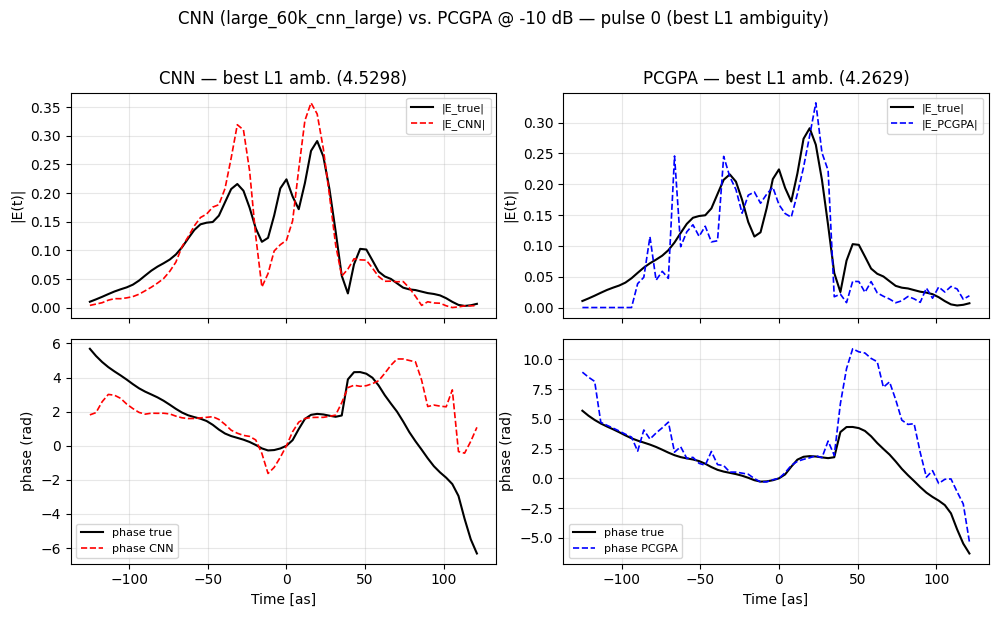

C:\Users\SharonLab\AppData\Local\Temp\ipykernel_178892\2541952071.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


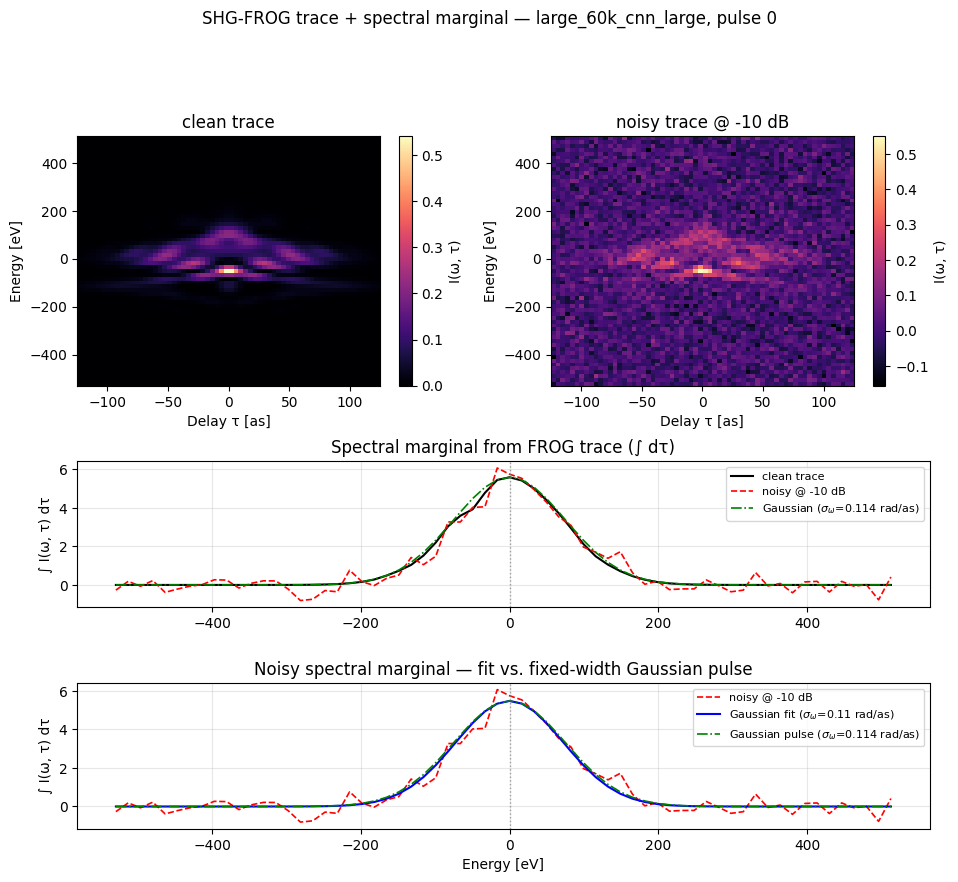

In [11]:
from train import load_checkpoint
from pulse_metrics import (
    best_l1_ambiguity_field,
    frog_trace_marginals,
    l1_packed_mae,
    packed_batch_to_complex,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)

if "reconstruct_pcgpa" not in globals():
    import pcgpa_reconstruct

    _pcgpa_mod = pcgpa_reconstruct.reload_from_disk()
    reconstruct_pcgpa = _pcgpa_mod.reconstruct_pcgpa
    _pcgpa_rng_for_pulse = _pcgpa_mod._pcgpa_rng_for_pulse

_low_snr_exp = next(
    (e for e in EXPERIMENTS if e["name"] == "large_60k_cnn_large"),
    {
        "name": "large_60k_cnn_large",
        "checkpoint": "checkpoints/large_60k_cnn_large.pt",
    },
)
_PLOT_SNR_DB = -10.0
_plot_i = 0

_model_large, _ = load_checkpoint(_low_snr_exp["checkpoint"], DEVICE)
_model_large.eval()

with torch.no_grad():
    I_clean_1 = I_test[_plot_i : _plot_i + 1]
    I_n = add_trace_noise(I_clean_1, _PLOT_SNR_DB)
    E_pred = _model_large(I_n.unsqueeze(1))

_i_noisy_np = I_n.squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())
e_rec = packed_batch_to_complex(E_pred)[0]
e_rec_amb = best_l1_ambiguity_field(e_rec, e_true)

print(
    f"Running PCGPA @ {_PLOT_SNR_DB:.0f} dB "
    f"(maxiter={PCGPA_MAXITER}, restarts={PCGPA_N_RESTARTS}) …"
)
e_pcgpa = reconstruct_pcgpa(
    _i_noisy_np,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_restarts=PCGPA_N_RESTARTS,
    rng=_pcgpa_rng_for_pulse(SEED, _plot_i, _PLOT_SNR_DB),
)
e_pcgpa_amb = best_l1_ambiguity_field(e_pcgpa, e_true)
_e_true_packed = E_test[_plot_i].cpu().numpy()

_l1_cnn = l1_packed_mae(e_rec_amb, _e_true_packed, use_best_ambiguity=False)
_l1_pcgpa = l1_packed_mae(e_pcgpa_amb, _e_true_packed, use_best_ambiguity=False)
print(
    f"L1 @ {_PLOT_SNR_DB:.0f} dB, pulse {_plot_i} ({_low_snr_exp['name']}): "
    f"CNN L1-best={_l1_cnn:.5f}  PCGPA L1-best={_l1_pcgpa:.5f}"
)

t_axis = t_vec
_ph_true, _ = unwrap_phases_for_overlay(e_rec_amb, e_true)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for col, e_r, color, name, val in (
    (0, e_rec_amb, "r", "CNN", _l1_cnn),
    (1, e_pcgpa_amb, "b", "PCGPA", _l1_pcgpa),
):
    axes[0, col].plot(t_axis, np.abs(e_true), "k-", lw=1.5, label="|E_true|")
    axes[0, col].plot(t_axis, np.abs(e_r), color + "--", lw=1.2, label=f"|E_{name}|")
    axes[0, col].set_title(f"{name} — best L1 amb. ({val:.4f})")
    axes[0, col].set_ylabel("|E(t)|")
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True, alpha=0.3)

    _, ph_rec = unwrap_phases_for_overlay(e_r, e_true)
    axes[1, col].plot(t_axis, _ph_true, "k-", lw=1.5, label="phase true")
    axes[1, col].plot(t_axis, ph_rec, color + "--", lw=1.2, label=f"phase {name}")
    axes[1, col].set_xlabel("Time [as]")
    axes[1, col].set_ylabel("phase (rad)")
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(True, alpha=0.3)

fig.suptitle(
    f"CNN ({_low_snr_exp['name']}) vs. PCGPA @ {_PLOT_SNR_DB:.0f} dB — "
    f"pulse {_plot_i} (best L1 ambiguity)",
    y=1.02,
)
plt.tight_layout()
plt.show()

# FROG trace (τ [as], Energy [eV]) + spectral marginal from clean/noisy traces
from matplotlib.gridspec import GridSpec

_i_clean_np = I_clean_1.squeeze(0).cpu().numpy()
_trace_clean, _tau_as, _ = prepare_frog_trace_for_plot(
    _i_clean_np, omega_axis=w_vec, dt=DT
)
_trace_noisy, _, _ = prepare_frog_trace_for_plot(_i_noisy_np, omega_axis=w_vec, dt=DT)

# w_vec is already fftshift-centered (0 at middle); match trace_plot rows after fftshift(ω)
_omega_eV = np.asarray(w_vec, dtype=float) * ENERGY_SCALE_EV
_extent_ev = [_tau_as[0], _tau_as[-1], _omega_eV[0], _omega_eV[-1]]

_spec_clean, _ = frog_trace_marginals(_trace_clean)
_spec_noisy, _ = frog_trace_marginals(_trace_noisy)

_sigma_w = np.sqrt(2) * 0.05 * (2 * np.pi / DT)  # √2 × sigma_w from pulses_generator_NB.ipynb
_sigma_w_eV = _sigma_w * ENERGY_SCALE_EV
_gauss_spec = np.exp(-0.5 * (_omega_eV / _sigma_w_eV) ** 2)
_gauss_spec *= np.max(_spec_clean) / np.max(_gauss_spec)

from scipy.optimize import curve_fit

def _gauss_amp_sigma(E, amp, sigma_eV):
    return amp * np.exp(-0.5 * (E / sigma_eV) ** 2)

_fit_popt, _ = curve_fit(
    _gauss_amp_sigma,
    _omega_eV,
    _spec_noisy,
    p0=(float(np.max(_spec_noisy)), float(_sigma_w_eV)),
    bounds=([0.0, 1e-9], [np.inf, np.inf]),
    maxfev=10_000,
)
_fit_noisy = _gauss_amp_sigma(_omega_eV, *_fit_popt)

_gauss_pulse = np.exp(-0.5 * (_omega_eV / _sigma_w_eV) ** 2)
_gauss_pulse *= np.max(_fit_noisy) / np.max(_gauss_pulse)

fig_tr = plt.figure(figsize=(11, 9))
_gs = GridSpec(3, 2, figure=fig_tr, height_ratios=[1.2, 0.7, 0.7], hspace=0.42, wspace=0.25)
_ax_tc = fig_tr.add_subplot(_gs[0, 0])
_ax_tn = fig_tr.add_subplot(_gs[0, 1])
_ax_spec = fig_tr.add_subplot(_gs[1, :])
_ax_spec_fit = fig_tr.add_subplot(_gs[2, :])

for ax, tr, title in (
    (_ax_tc, _trace_clean, "clean trace"),
    (_ax_tn, _trace_noisy, f"noisy trace @ {_PLOT_SNR_DB:.0f} dB"),
):
    im = ax.imshow(tr, origin="lower", aspect="auto", extent=_extent_ev, cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("Delay τ [as]")
    ax.set_ylabel("Energy [eV]")
    fig_tr.colorbar(im, ax=ax, label="I(ω, τ)")

_ax_spec.plot(_omega_eV, _spec_clean, "k-", lw=1.5, label="clean trace")
_ax_spec.plot(_omega_eV, _spec_noisy, "r--", lw=1.2, label=f"noisy @ {_PLOT_SNR_DB:.0f} dB")
_ax_spec.plot(
    _omega_eV,
    _gauss_spec,
    "g-.",
    lw=1.2,
    label=rf"Gaussian ($\sigma_\omega$={_sigma_w:.3g} rad/as)",
)
_ax_spec.set_title("Spectral marginal from FROG trace (∫ dτ)")
_ax_spec.set_ylabel("∫ I(ω, τ) dτ")
_ax_spec.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7)
_ax_spec.legend(fontsize=8)
_ax_spec.grid(True, alpha=0.3)

_fit_sigma_w = _fit_popt[1] / ENERGY_SCALE_EV
_ax_spec_fit.plot(_omega_eV, _spec_noisy, "r--", lw=1.2, label=f"noisy @ {_PLOT_SNR_DB:.0f} dB")
_ax_spec_fit.plot(
    _omega_eV,
    _fit_noisy,
    "b-",
    lw=1.5,
    label=rf"Gaussian fit ($\sigma_\omega$={_fit_sigma_w:.3g} rad/as)",
)
_ax_spec_fit.plot(
    _omega_eV,
    _gauss_pulse,
    "g-.",
    lw=1.2,
    label=rf"Gaussian pulse ($\sigma_\omega$={_sigma_w:.3g} rad/as)",
)
_ax_spec_fit.set_title("Noisy spectral marginal — fit vs. fixed-width Gaussian pulse")
_ax_spec_fit.set_xlabel("Energy [eV]")
_ax_spec_fit.set_ylabel("∫ I(ω, τ) dτ")
_ax_spec_fit.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7)
_ax_spec_fit.legend(fontsize=8)
_ax_spec_fit.grid(True, alpha=0.3)

fig_tr.suptitle(
    f"SHG-FROG trace + spectral marginal — {_low_snr_exp['name']}, pulse {_plot_i}",
    y=1.02,
)
plt.tight_layout()
plt.show()

## CNN recovered vs. true @ 30 dB (per experiment)

Same test pulse and SNR as above: **|E(t)|** and **phase** for each CNN checkpoint (best-L1 ambiguity alignment). Run after the data cell and `EXPERIMENTS` hyperparameters.

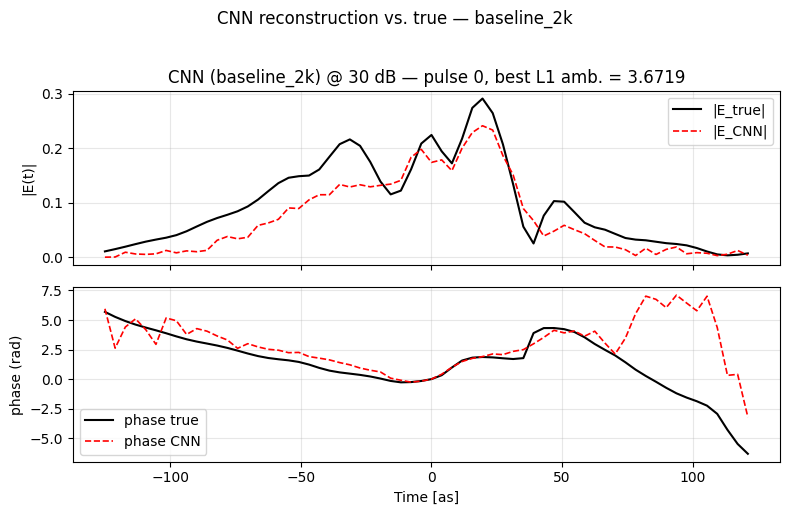

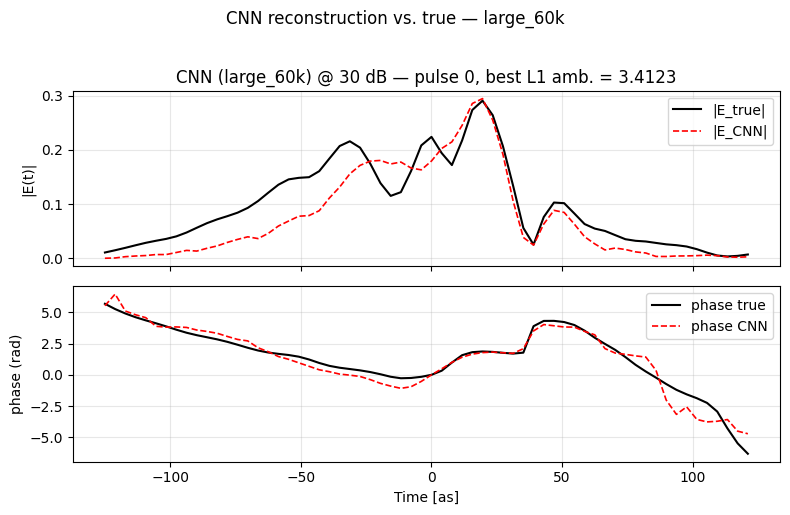

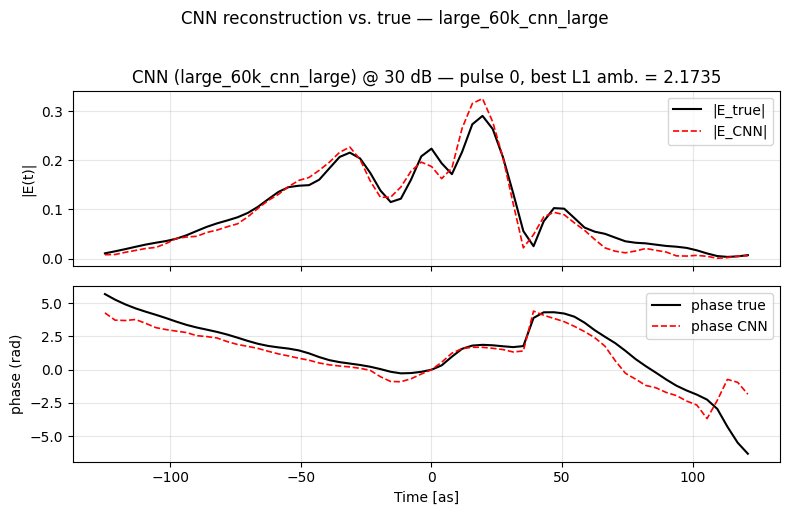

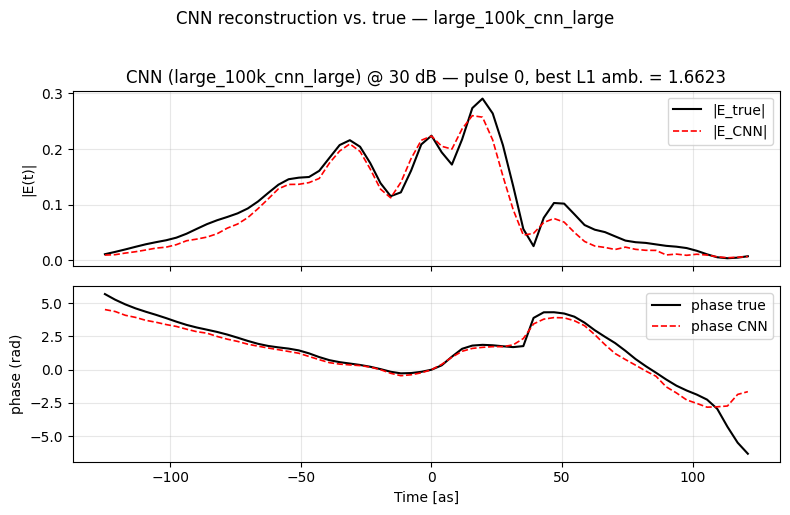

In [12]:
from pathlib import Path

from train import load_checkpoint
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    packed_batch_to_complex,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)

_PLOT_SNR_DB = 30.0
_plot_i = 0

I_clean_1 = I_test[_plot_i : _plot_i + 1]
I_noisy_30 = add_trace_noise(I_clean_1, _PLOT_SNR_DB)
e_true = unpack_packed_field(E_test[_plot_i].cpu().numpy())
t_axis = t_vec

for exp in EXPERIMENTS:
    ckpt = Path(exp["checkpoint"])
    if not ckpt.is_file():
        print(f"Skip {exp['name']}: missing {ckpt}")
        continue

    exp_model, _ = load_checkpoint(ckpt, DEVICE)
    exp_model.eval()
    with torch.no_grad():
        E_pred = exp_model(I_noisy_30.unsqueeze(1))

    e_rec = packed_batch_to_complex(E_pred)[0]
    e_rec_amb = best_l1_ambiguity_field(e_rec, e_true)
    l1_best = best_l1_ambiguity(e_rec, e_true)
    ph_true, ph_rec = unwrap_phases_for_overlay(e_rec_amb, e_true)

    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].plot(t_axis, np.abs(e_true), "k-", lw=1.5, label="|E_true|")
    axes[0].plot(t_axis, np.abs(e_rec_amb), "r--", lw=1.2, label="|E_CNN|")
    axes[0].set_ylabel("|E(t)|")
    axes[0].set_title(
        f"CNN ({exp['name']}) @ {_PLOT_SNR_DB:.0f} dB — pulse {_plot_i}, "
        f"best L1 amb. = {l1_best:.4f}"
    )
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_axis, ph_true, "k-", lw=1.5, label="phase true")
    axes[1].plot(t_axis, ph_rec, "r--", lw=1.2, label="phase CNN")
    axes[1].set_xlabel("Time [as]")
    axes[1].set_ylabel("phase (rad)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"CNN reconstruction vs. true — {exp['name']}", y=1.02)
    plt.tight_layout()
    plt.show()

**trace SNR (dB)** — see **Trace SNR, AWGN, and SNR$_1$** (earlier in this notebook). Summary: clean trace $I_{\mathrm{clean}}$ from `FROGNet`; $\bar I=\mathrm{mean}(I_{\mathrm{clean}})$; amplitude SNR $\rho=10^{\mathrm{SNR}_{\mathrm{dB}}/20}=\bar I/\sigma_n$; AWGN with $\sigma_n=\bar I/\rho$; $I_{\mathrm{noisy}}=I_{\mathrm{clean}}+n$, $n\sim\mathcal{N}(0,\sigma_n^2)$.

**equivalent pulse count $N_{\mathrm{eq}}$** — from the same trace SNR (dB $\to$ $\rho=10^{\mathrm{SNR}_{\mathrm{dB}}/20}$) and single-pulse $\rho_1=A_{s1}/\sigma_{n1}$ with $A_{s1}=\eta N_{\mathrm{ph}}$ ($=10^{-12}\times10^{12}$) and $\sigma_{n1}=80\,A_{s1}$:

$$
N_{\mathrm{eq}} = \left( \frac{\rho}{\rho_1} \right)^2
= \left( \frac{10^{\mathrm{SNR}_{\mathrm{dB}}/20}}{\rho_1} \right)^2,
\qquad
\rho_1 = \frac{A_{s1}}{\sigma_{n1}} = \frac{1}{80}
$$

Plots use a **logarithmic** $N_{\mathrm{eq}}$ axis (`snr_db_to_equivalent_n_pulses`).


d:\Haim\Haim 3rd paper\Ultra-Fast project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded PCGPA sweep from checkpoints\pcgpa_snr_sweep.npz
Sweep — PCGPA n=32 (always best amb.), CNN n=512 per experiment


PCGPA SNR sweep: 100%|██████████| 9/9 [00:00<?, ?it/s]


Loaded CNN sweep for baseline_2k: checkpoints\baseline_2k_cnn_sweep.npz
Loaded CNN sweep for large_60k: checkpoints\large_60k_cnn_sweep.npz
Loaded CNN sweep for large_60k_cnn_large: checkpoints\large_60k_cnn_large_cnn_sweep.npz
Loaded CNN sweep for large_100k_cnn_large: checkpoints\large_100k_cnn_large_cnn_sweep.npz
baseline_2k: max |sim raw − amb| = 0.073110
large_60k: max |sim raw − amb| = 0.088983
large_60k_cnn_large: max |sim raw − amb| = 0.091602
large_100k_cnn_large: max |sim raw − amb| = 0.117296


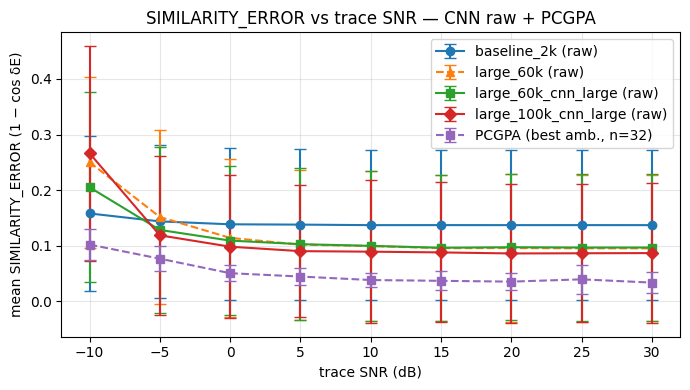

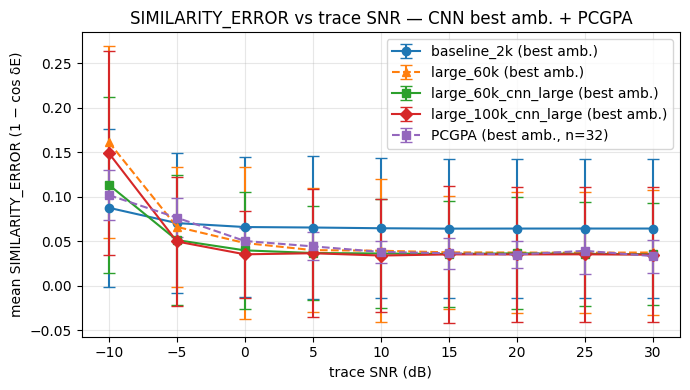

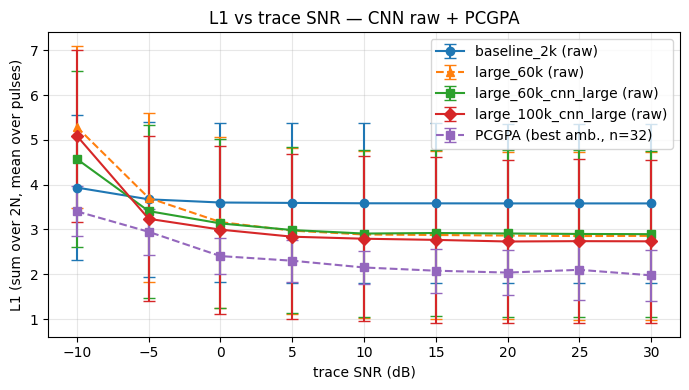

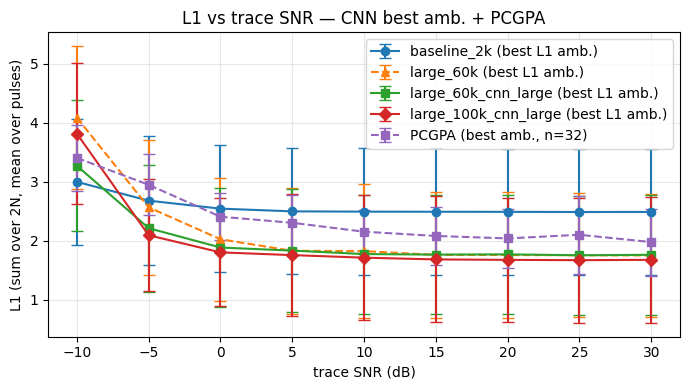

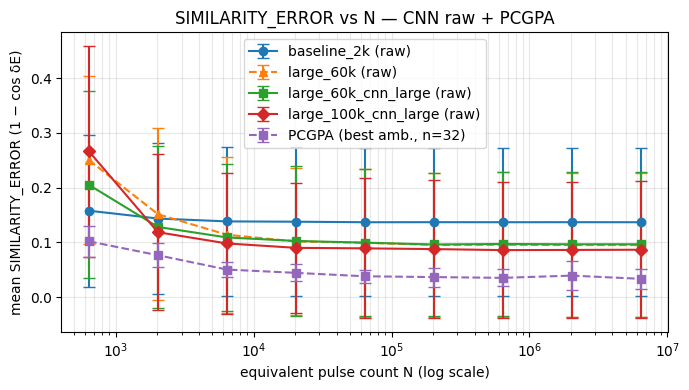

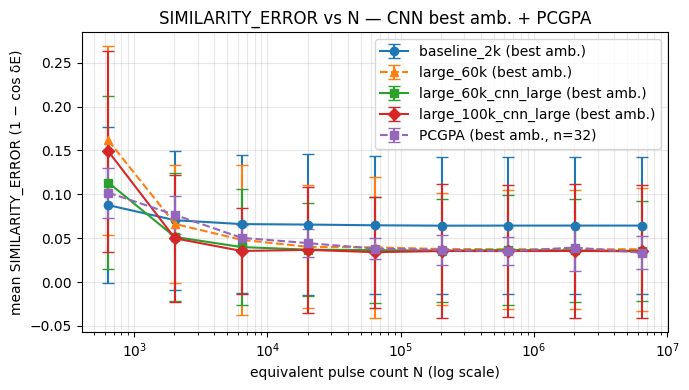

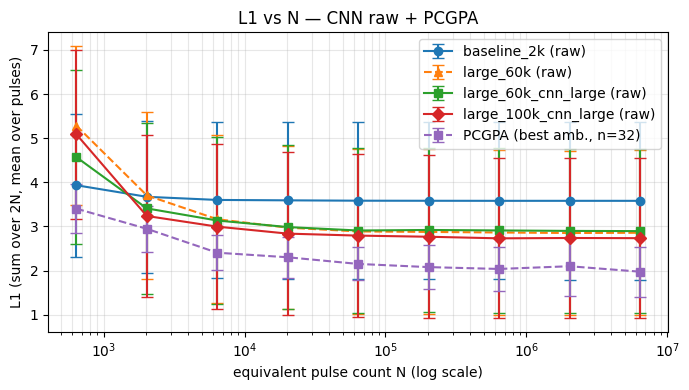

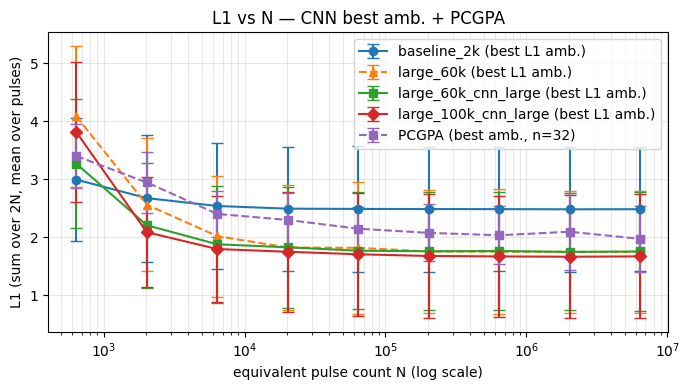

In [13]:
from pathlib import Path

from evaluate_cnn import (
    load_cnn_sweep,
    plot_standard_cnn_vs_pcgpa_suite,
    run_cnn_snr_sweep,
    save_cnn_sweep,
)
from train import load_checkpoint

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kwargs):
        return x

import pcgpa_reconstruct

_pcgpa = pcgpa_reconstruct.reload_from_disk()
mean_metrics_at_snr_pcgpa = _pcgpa.mean_metrics_at_snr_pcgpa
if getattr(_pcgpa, "PCGPA_API_VERSION", 0) < 6:
    raise RuntimeError(
        f"Stale pcgpa at {_pcgpa.__file__} (API v{getattr(_pcgpa, 'PCGPA_API_VERSION', '?')}); "
        "restart kernel and re-run smoke cell"
    )

_i_test_np = I_test.cpu().numpy()
_e_test_np = E_test.cpu().numpy()

_pcgpa_kw = dict(
    add_noise_fn=add_trace_noise,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_subsample=PCGPA_N_TEST,
    n_restarts=PCGPA_N_RESTARTS,
    seed=SEED,
)

# --- PCGPA sweep (once, shared baseline) ---
pcgpa_sim_m, pcgpa_sim_s = [], []
pcgpa_l1_m, pcgpa_l1_s = [], []

_cache_path = Path(PCGPA_SWEEP_CACHE)
_pcgpa_loaded = False
if RUN_PCGPA_SWEEP and _cache_path.is_file() and not FORCE_RECOMPUTE_PCGPA:
    _z = np.load(_cache_path, allow_pickle=False)
    if np.array_equal(_z["snr_sweep_db"], SNR_SWEEP_DB):
        pcgpa_sim_m = list(_z["pcgpa_sim_m"])
        pcgpa_sim_s = list(_z["pcgpa_sim_s"])
        pcgpa_l1_m = list(_z["pcgpa_l1_m"])
        pcgpa_l1_s = list(_z["pcgpa_l1_s"])
        _pcgpa_loaded = True
        print(f"Loaded PCGPA sweep from {_cache_path}")

print(
    f"Sweep — PCGPA n={PCGPA_N_TEST} (always best amb.), "
    f"CNN n={N_TEST} per experiment"
)
if RUN_PCGPA_SWEEP and not _pcgpa_loaded:
    _n_pcgpa = len(SNR_SWEEP_DB) * PCGPA_N_TEST
    print(
        f"PCGPA: {_n_pcgpa} reconstructions "
        f"({len(SNR_SWEEP_DB)} SNR × {PCGPA_N_TEST} pulses) — may take a long time on CPU"
    )
elif not RUN_PCGPA_SWEEP:
    print("RUN_PCGPA_SWEEP=False — skipping PCGPA (plots need cached curves)")

for snr_db in tqdm(SNR_SWEEP_DB, desc="PCGPA SNR sweep"):
    if RUN_PCGPA_SWEEP and not _pcgpa_loaded:
        (sm, ss), (lm, ls) = mean_metrics_at_snr_pcgpa(
            _i_test_np,
            _e_test_np,
            float(snr_db),
            use_best_ambiguity=True,
            show_progress=True,
            **_pcgpa_kw,
        )
        pcgpa_sim_m.append(sm)
        pcgpa_sim_s.append(ss)
        pcgpa_l1_m.append(lm)
        pcgpa_l1_s.append(ls)

if RUN_PCGPA_SWEEP and not _pcgpa_loaded:
    _cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        _cache_path,
        snr_sweep_db=SNR_SWEEP_DB,
        pcgpa_sim_m=np.asarray(pcgpa_sim_m),
        pcgpa_sim_s=np.asarray(pcgpa_sim_s),
        pcgpa_l1_m=np.asarray(pcgpa_l1_m),
        pcgpa_l1_s=np.asarray(pcgpa_l1_s),
        pcgpa_n_test=PCGPA_N_TEST,
        pcgpa_maxiter=PCGPA_MAXITER,
        pcgpa_n_restarts=PCGPA_N_RESTARTS,
    )
    print(f"Saved PCGPA sweep to {_cache_path}")

# --- CNN sweep per experiment (baseline + advanced, side by side) ---
cnn_results = []
for exp in EXPERIMENTS:
    ckpt = Path(exp["checkpoint"])
    if not ckpt.is_file():
        print(f"Skip {exp['name']}: missing {ckpt}")
        continue
    exp_model, _ = load_checkpoint(ckpt, DEVICE)
    cache = Path(exp["sweep_cache"])
    if cache.is_file() and not exp.get("force_recompute_sweep", False):
        res = load_cnn_sweep(cache)
        print(f"Loaded CNN sweep for {exp['name']}: {cache}")
    else:
        print(f"Computing CNN sweep for {exp['name']} …")
        res = run_cnn_snr_sweep(
            exp_model,
            test_loader,
            SNR_SWEEP_DB,
            experiment_name=exp["name"],
            add_noise_fn=add_trace_noise,
            verbose=False,
        )
        save_cnn_sweep(cache, res)
        print(f"Saved CNN sweep: {cache}")
    cnn_results.append(res)

if not cnn_results:
    raise RuntimeError("No CNN experiment checkpoints found.")

for res in cnn_results:
    diff = float(np.max(np.abs(res.cnn_sim_raw_m - res.cnn_sim_amb_m)))
    print(f"{res.experiment_name}: max |sim raw − amb| = {diff:.6f}")

_pcgpa_lbl = f"PCGPA (best amb., n={PCGPA_N_TEST})"
plot_standard_cnn_vs_pcgpa_suite(
    SNR_SWEEP_DB,
    cnn_results,
    pcgpa_sim_m=pcgpa_sim_m,
    pcgpa_sim_s=pcgpa_sim_s,
    pcgpa_l1_m=pcgpa_l1_m,
    pcgpa_l1_s=pcgpa_l1_s,
    pcgpa_label=_pcgpa_lbl,
)


## PCGPA: initial-guess comparison (PCGPA only)

Overlay **PCGPA reconstruction error vs. trace SNR** for four initial-guess strategies (no CNN):

1. **dataset σ_ω** — current default: Gaussian spectrum with width `SIGMA_OMEGA` (+ FWHM jitter across restarts).
2. **trace marginal × √2** — fit Gaussian to the **noisy** trace spectral marginal; use `√2 × σ_fit`.
3. **random spectral width** — random `σ_ω` per restart (absolute range, independent of dataset / trace).
4. **random initial guess** — random Gaussian envelope width via `fwhm_scale_range` jitter around a dt-only nominal (**no** dataset `σ_ω` prior).

Run after the data cell (`I_test`, `E_test`, `w_vec`) and hyperparameters. Cached in `PCGPA_INIT_COMPARE_CACHE`.

PCGPA init-guess comparison: 3 modes × 9 SNR × 32 pulses


PCGPA init: random_width: 100%|██████████| 9/9 [02:27<00:00, 16.43s/it]


Saved PCGPA init-guess comparison to checkpoints\pcgpa_init_guess_compare.npz


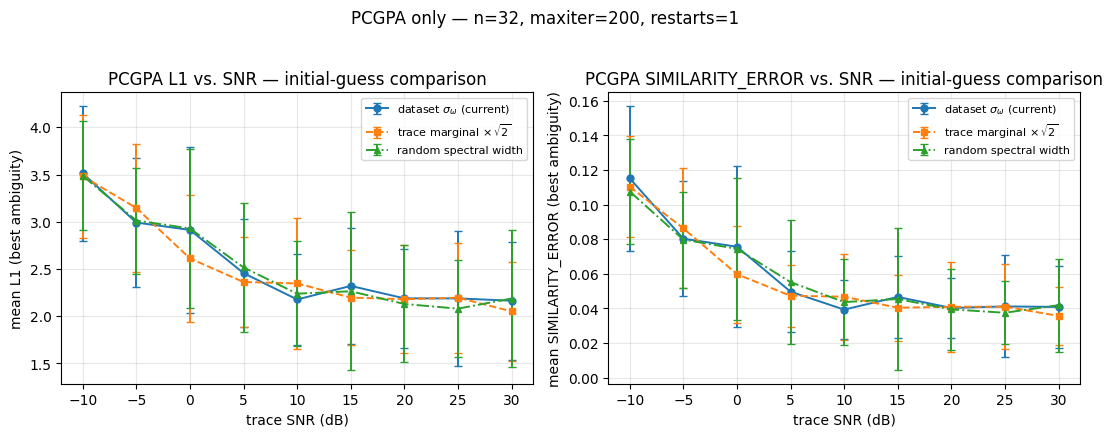

In [14]:
from pathlib import Path

import pcgpa_reconstruct

_pcgpa_init = pcgpa_reconstruct.reload_from_disk()
mean_metrics_at_snr_pcgpa = _pcgpa_init.mean_metrics_at_snr_pcgpa
if getattr(_pcgpa_init, "PCGPA_API_VERSION", 0) < 6:
    raise RuntimeError(
        f"Need PCGPA_API_VERSION >= 6 (got {getattr(_pcgpa_init, 'PCGPA_API_VERSION', '?')}); "
        "restart kernel and re-run the PCGPA smoke cell"
    )

_i_test_np = I_test.cpu().numpy()
_e_test_np = E_test.cpu().numpy()
_w_vec_np = np.asarray(w_vec, dtype=float)

PCGPA_INIT_SCENARIOS = [
    ("dataset_sigma", r"dataset $\sigma_\omega$ (current)"),
    ("trace_marginal_sqrt2", r"trace marginal $\times\,\sqrt{2}$"),
    ("random_width", "random spectral width"),
    ("random_initial", "random initial guess"),
]

_init_kw = dict(
    add_noise_fn=add_trace_noise,
    dt=DT,
    sigma_omega=SIGMA_OMEGA,
    maxiter=PCGPA_MAXITER,
    n_subsample=PCGPA_N_TEST,
    n_restarts=PCGPA_INIT_N_RESTARTS,
    seed=SEED,
    use_best_ambiguity=True,
    omega_axis=_w_vec_np,
)

_pcgpa_init_results: dict[str, dict] = {}
_cache_init = Path(PCGPA_INIT_COMPARE_CACHE)
_loaded_init = False

if RUN_PCGPA_INIT_COMPARE and _cache_init.is_file() and not FORCE_RECOMPUTE_PCGPA_INIT:
    _z = np.load(_cache_init, allow_pickle=False)
    _modes_in_cache = {m for m, _ in PCGPA_INIT_SCENARIOS if f"{m}_l1_m" in _z.files}
    if np.array_equal(_z["snr_sweep_db"], SNR_SWEEP_DB) and len(_modes_in_cache) == len(
        PCGPA_INIT_SCENARIOS
    ):
        for mode, _ in PCGPA_INIT_SCENARIOS:
            _pcgpa_init_results[mode] = {
                "l1_m": list(_z[f"{mode}_l1_m"]),
                "l1_s": list(_z[f"{mode}_l1_s"]),
                "sim_m": list(_z[f"{mode}_sim_m"]),
                "sim_s": list(_z[f"{mode}_sim_s"]),
            }
        _loaded_init = True
        print(f"Loaded PCGPA init-guess comparison from {_cache_init}")
    elif _modes_in_cache:
        print(
            f"Cache {_cache_init} missing modes "
            f"{[m for m, _ in PCGPA_INIT_SCENARIOS if m not in _modes_in_cache]} — recomputing"
        )

if RUN_PCGPA_INIT_COMPARE and not _loaded_init:
    print(
        f"PCGPA init-guess comparison: {len(PCGPA_INIT_SCENARIOS)} modes × "
        f"{len(SNR_SWEEP_DB)} SNR × {PCGPA_N_TEST} pulses"
    )
    for mode, _label in PCGPA_INIT_SCENARIOS:
        l1_m, l1_s, sim_m, sim_s = [], [], [], []
        for snr_db in tqdm(SNR_SWEEP_DB, desc=f"PCGPA init: {mode}"):
            (sm, ss), (lm, ls) = mean_metrics_at_snr_pcgpa(
                _i_test_np,
                _e_test_np,
                float(snr_db),
                initial_guess_mode=mode,
                show_progress=True,
                **_init_kw,
            )
            sim_m.append(sm)
            sim_s.append(ss)
            l1_m.append(lm)
            l1_s.append(ls)
        _pcgpa_init_results[mode] = {
            "l1_m": l1_m,
            "l1_s": l1_s,
            "sim_m": sim_m,
            "sim_s": sim_s,
        }

    _cache_init.parent.mkdir(parents=True, exist_ok=True)
    _save_init = {"snr_sweep_db": SNR_SWEEP_DB}
    for mode, _ in PCGPA_INIT_SCENARIOS:
        _r = _pcgpa_init_results[mode]
        _save_init[f"{mode}_l1_m"] = np.asarray(_r["l1_m"])
        _save_init[f"{mode}_l1_s"] = np.asarray(_r["l1_s"])
        _save_init[f"{mode}_sim_m"] = np.asarray(_r["sim_m"])
        _save_init[f"{mode}_sim_s"] = np.asarray(_r["sim_s"])
    np.savez(_cache_init, **_save_init)
    print(f"Saved PCGPA init-guess comparison to {_cache_init}")
elif not RUN_PCGPA_INIT_COMPARE:
    print("RUN_PCGPA_INIT_COMPARE=False — skipping init-guess PCGPA sweep")

if _pcgpa_init_results:
    _styles = ["-o", "--s", "-.^", ":"]
    fig_init, axes_init = plt.subplots(1, 2, figsize=(11, 4.2))

    for (mode, label), sty in zip(PCGPA_INIT_SCENARIOS, _styles):
        _r = _pcgpa_init_results[mode]
        axes_init[0].errorbar(
            SNR_SWEEP_DB,
            _r["l1_m"],
            yerr=_r["l1_s"],
            fmt=sty,
            lw=1.4,
            ms=5,
            capsize=3,
            label=label,
        )
        axes_init[1].errorbar(
            SNR_SWEEP_DB,
            _r["sim_m"],
            yerr=_r["sim_s"],
            fmt=sty,
            lw=1.4,
            ms=5,
            capsize=3,
            label=label,
        )

    axes_init[0].set_xlabel("trace SNR (dB)")
    axes_init[0].set_ylabel("mean L1 (best ambiguity)")
    axes_init[0].set_title("PCGPA L1 vs. SNR — initial-guess comparison")
    axes_init[0].legend(fontsize=8)
    axes_init[0].grid(True, alpha=0.3)

    axes_init[1].set_xlabel("trace SNR (dB)")
    axes_init[1].set_ylabel("mean SIMILARITY_ERROR (best ambiguity)")
    axes_init[1].set_title("PCGPA SIMILARITY_ERROR vs. SNR — initial-guess comparison")
    axes_init[1].legend(fontsize=8)
    axes_init[1].grid(True, alpha=0.3)

    fig_init.suptitle(
        f"PCGPA only — n={PCGPA_N_TEST}, maxiter={PCGPA_MAXITER}, restarts={PCGPA_INIT_N_RESTARTS}",
        y=1.03,
    )
    plt.tight_layout()
    plt.show()

## CNN-only comparison (selected checkpoints)

Overlay **L1 vs. SNR** and **L1 vs. N** for models listed in `CNN_COMPARE_NAMES` only — no PCGPA, no baseline clutter. After `large_100k_cnn_large` finishes training, set `force_recompute_sweep: True` on that experiment (or delete its `.npz`) and re-run this cell.

Loaded large_60k_cnn_large: checkpoints\large_60k_cnn_large_cnn_sweep.npz
Loaded large_100k_cnn_large: checkpoints\large_100k_cnn_large_cnn_sweep.npz

L1 (best amb., mean over test) — selected SNR points:
  large_60k_cnn_large:
      -10 dB: 3.2710
        0 dB: 1.8828
       15 dB: 1.7626
       30 dB: 1.7594
  large_100k_cnn_large:
      -10 dB: 3.8164
        0 dB: 1.8004
       15 dB: 1.6809
       30 dB: 1.6737


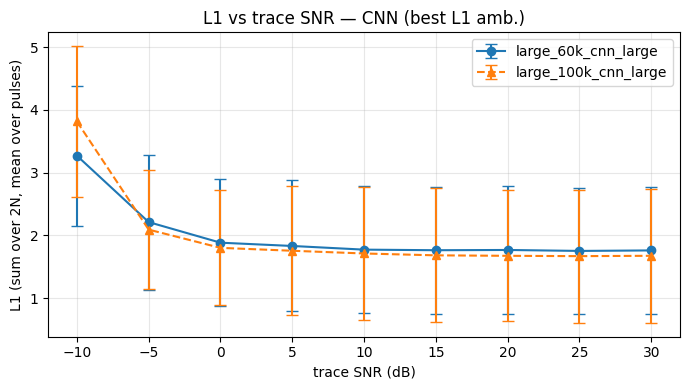

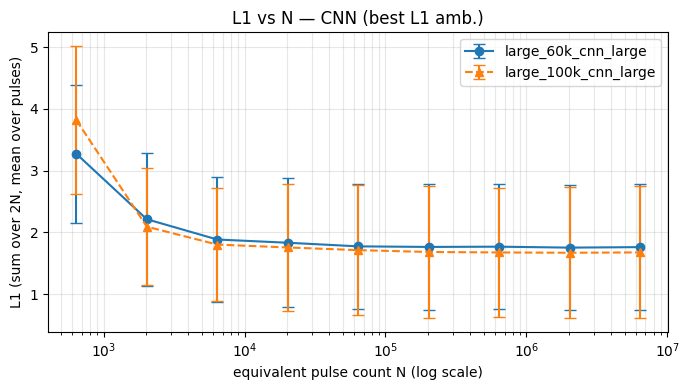

In [15]:
from pathlib import Path

from evaluate_cnn import (
    load_cnn_sweep,
    plot_cnn_snr_compare,
    run_cnn_snr_sweep,
    save_cnn_sweep,
)
from train import load_checkpoint

_cnn_compare: list = []
for _name in CNN_COMPARE_NAMES:
    _exp = next((e for e in EXPERIMENTS if e["name"] == _name), None)
    if _exp is None:
        print(f"Skip {_name}: not in EXPERIMENTS")
        continue
    _ckpt = Path(_exp["checkpoint"])
    if not _ckpt.is_file():
        print(f"Skip {_name}: missing checkpoint {_ckpt}")
        continue
    _cache = Path(_exp["sweep_cache"])
    if _cache.is_file() and not _exp.get("force_recompute_sweep", False):
        _res = load_cnn_sweep(_cache)
        print(f"Loaded {_name}: {_cache}")
    else:
        print(f"Computing CNN sweep for {_name} …")
        _m, _ = load_checkpoint(_ckpt, DEVICE)
        _res = run_cnn_snr_sweep(
            _m,
            test_loader,
            SNR_SWEEP_DB,
            experiment_name=_name,
            add_noise_fn=add_trace_noise,
            verbose=True,
        )
        save_cnn_sweep(_cache, _res)
        print(f"Saved {_cache}")
    _cnn_compare.append(_res)

if not _cnn_compare:
    raise RuntimeError("No CNN checkpoints available for CNN_COMPARE_NAMES.")

print("\nL1 (best amb., mean over test) — selected SNR points:")
for _res in _cnn_compare:
    print(f"  {_res.experiment_name}:")
    for _snr in (-10.0, 0.0, 15.0, 30.0):
        _idx = int(np.where(_res.snr_sweep_db == _snr)[0][0])
        print(f"    {_snr:5.0f} dB: {_res.cnn_l1_amb_m[_idx]:.4f}")

plot_cnn_snr_compare(_cnn_compare, use_best_l1_amb=True, include_vs_n=True)